# Procedural Frozen Lake

`Procedural-FrozenLake-v1` is a custom environment bundled with mouse-env. Unlike the standard `FrozenLake-v1` (fixed 4x4 map), it generates random valid maps with configurable grid size, hole placement, start positions, and goal rewards. By default, each env instance keeps its generated map across resets; pass `episode_reset_options={"regenerate_map": True}` on `EnvConfig` to generate a fresh random map every episode reset.

The env also includes built-in Q* support: pass `q_star_source={"provider": "env_q_star"}` and the env runs value iteration internally for each generated map, injecting exact optimal Q-values into every step output. When maps regenerate on reset, Q* is recomputed for the new map before the reset frame is emitted.

## Why this env is a good benchmark

Standard FrozenLake is a memorisation problem once the map is fixed. `Procedural-FrozenLake-v1` can make it a generalisation problem: with `episode_reset_options={"regenerate_map": True}`, the agent cannot memorise a single solution and must use the observation (its current state index on the current map) plus the Q* supervision signal to navigate correctly on layouts it has never seen.

Because Q* is recomputed per map and injected via `env_q_star`, this env supports exact imitation learning without any precomputation step — the env handles it internally on reset when map regeneration is enabled.

## How Q* stays fresh across resets

In mouse-env, the reset frame is the first output after an episode ends. For `Procedural-FrozenLake-v1` with `episode_reset_options={"regenerate_map": True}`, the reset frame already contains Q-values for the **new** map (not the one that just ended). This means `argmax(outputs[i]["info_env_q_star"])` is immediately valid on the reset frame — no extra step is needed to receive the new map's Q-values.

## Imports

In [1]:
import numpy as np
import torch

from mouse_envs import EnvConfig, make_env

## Build the environment

`step_penalty=-0.01` is passed via `kwargs`, and `episode_reset_options={"regenerate_map": True}` asks each episode reset to generate a new map. Without a step penalty the env solves with `gamma=1.0`, so every hole-avoiding action shares the same Q* value and greedy tie-breaking can wander. A small penalty makes value iteration prefer shorter paths, turning `argmax(info_env_q_star)` into a true shortest-path expert.

In [2]:
cfg = EnvConfig(
    id="Procedural-FrozenLake-v1",
    seed=7,
    num_envs=1,
    episodes_per_task=100,
    q_star_source={"provider": "env_q_star"},
    episode_reset_options={"regenerate_map": True},
    kwargs={
        "step_penalty": -0.01,
        "max_episode_steps": 200,
    },
)
env = make_env(cfg)

## Inspect the reset frame

The first `step` performs the internal reset and already includes `info_env_q_star` for the start state of the first randomly generated map.

In [3]:
outputs = env.step(env.sample_random_inputs())

print(f"observation (state index): {outputs[0]['observation'].tolist()}")
print(f"q_star:                    {outputs[0]['info_env_q_star'].round(3)}")
print(f"greedy action:             {int(np.argmax(outputs[0]['info_env_q_star']))}")

observation (state index): 12
q_star:                    [ 0.95  0.95 -0.01  0.97]
greedy action:             3


## Inspect the map

Pass `emit_map=True` via `kwargs` to receive the board layout in `outputs[i]["info_map"]` on the first step after construction. The value is a JSON string with `"board"` (list of row strings using `S`/`F`/`H`/`G`) and `"rewards"` (goal state index → reward). With the default fixed-per-env behavior this fires once; with `episode_reset_options={"regenerate_map": True}`, it fires on each reset frame after a new map is created.

In [4]:
import json

cfg_map = EnvConfig(
    id="Procedural-FrozenLake-v1",
    seed=7,
    num_envs=1,
    episodes_per_task=100,
    q_star_source={"provider": "env_q_star"},
    episode_reset_options={"regenerate_map": True},
    kwargs={
        "step_penalty": -0.01,
        "max_episode_steps": 200,
        "emit_map": True,
    },
)
env_map = make_env(cfg_map)

# First step returns the map on the reset frame.
map_outputs = env_map.step(env_map.sample_random_inputs())
map_data = json.loads(map_outputs[0]["info_map"])

board = map_data["board"]
rewards = map_data["rewards"]

print("Board:")
for row in board:
    print("  " + " ".join(row))
print(f"\nGrid size: {len(board)} rows × {len(board[0])} cols")
print(f"Goal rewards: { {k: round(v, 3) for k, v in rewards.items()} }")
print(f"\nobservation (start state): {map_outputs[0]['observation'].tolist()}")
print(f"q_star at start:           {map_outputs[0]['info_env_q_star'].round(3)}")

env_map.close()

Board:
  H G F F H
  F H F H H
  F F S H F
  F F F F F

Grid size: 4 rows × 5 cols
Goal rewards: {'1': 1.0}

observation (start state): 12
q_star at start:           [ 0.95  0.95 -0.01  0.97]


## Expert rollout across episodes

Because this config uses `episode_reset_options={"regenerate_map": True}`, each time an episode ends the env resets to a **new random map** and value iteration recomputes Q* for that map. `info_env_q_star` in the reset frame already reflects the new layout, so greedy `argmax` is immediately valid without any extra steps.

In [5]:
episodes = 0

for step in range(400):
    inputs = [{
        "action": torch.tensor(int(np.argmax(outputs[0]["info_env_q_star"])), dtype=torch.int64)
    }]
    outputs = env.step(inputs)

    r = outputs[0]
    if r["done"].item() != 0:
        episodes += 1
        done_code = r["done"].item()
        outcome = "terminated" if done_code in (1, 3) else "truncated"
        print(
            f"step={step:3d}  episode={episodes}  outcome={outcome}  "
            f"reward={r['reward'].item():.2f}"
        )

step=  2  episode=1  outcome=terminated  reward=0.99
step=  6  episode=2  outcome=terminated  reward=0.99
step= 10  episode=3  outcome=terminated  reward=0.99
step= 14  episode=4  outcome=terminated  reward=0.99
step= 18  episode=5  outcome=terminated  reward=0.99
step= 22  episode=6  outcome=terminated  reward=0.99
step= 26  episode=7  outcome=terminated  reward=0.99
step= 30  episode=8  outcome=terminated  reward=0.99
step= 34  episode=9  outcome=terminated  reward=0.99
step= 38  episode=10  outcome=terminated  reward=0.99
step= 42  episode=11  outcome=terminated  reward=0.99
step= 46  episode=12  outcome=terminated  reward=0.99
step= 50  episode=13  outcome=terminated  reward=0.99
step= 54  episode=14  outcome=terminated  reward=0.99
step= 58  episode=15  outcome=terminated  reward=0.99
step= 62  episode=16  outcome=terminated  reward=0.99
step= 66  episode=17  outcome=terminated  reward=0.99
step= 70  episode=18  outcome=terminated  reward=0.99
step= 74  episode=19  outcome=termina

## With vs without the expert

To quantify what the Q* attachment provides, run many episodes two ways and compare episode success rate (FrozenLake gives `reward = 1` only on reaching the goal): **with the expert** (greedy `argmax` over `info_env_q_star`) vs **without** (random actions). The greedy-Q* policy requires no trained network — it reads exact Q-values the wrapper attaches each step, freshly computed for each new map when reset regeneration is enabled.

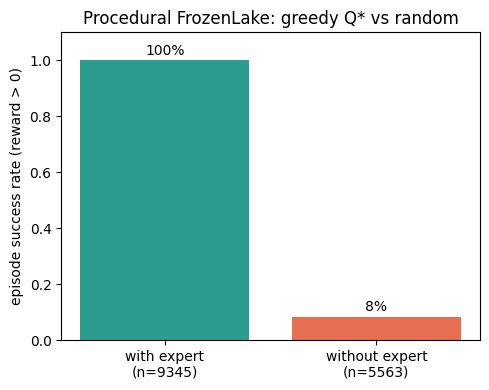

In [6]:
import matplotlib.pyplot as plt


def evaluate(use_expert, *, steps=800, seed=7, num_envs=64):
    cfg = EnvConfig(
        id="Procedural-FrozenLake-v1",
        seed=seed,
        num_envs=num_envs,
        episodes_per_task=100,
        q_star_source={"provider": "env_q_star"},
        episode_reset_options={"regenerate_map": True},
        kwargs={
            "step_penalty": -0.01,
            "max_episode_steps": 200,
        },
    )
    env = make_env(cfg)
    outputs = env.step(env.sample_random_inputs())
    for _ in range(steps):
        if use_expert:
            inputs = [{
                "action": torch.tensor(
                    int(np.argmax(outputs[i]["info_env_q_star"])),
                    dtype=torch.int64,
                )
            } for i in range(env.num_envs)]
        else:
            inputs = env.sample_random_inputs()
        outputs = env.step(inputs)
    all_rewards = [r for env_rewards in env.tracker.episode_cum_rewards for r in env_rewards]
    env.close()
    return np.array(all_rewards)


expert_eps = evaluate(use_expert=True)
random_eps = evaluate(use_expert=False)

success = [float((expert_eps > 0).mean()), float((random_eps > 0).mean())]
labels = [f"with expert\n(n={len(expert_eps)})", f"without expert\n(n={len(random_eps)})"]

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(labels, success, color=["#2a9d8f", "#e76f51"])
ax.set_ylim(0, 1.1)
ax.set_ylabel("episode success rate (reward > 0)")
ax.set_title("Procedural FrozenLake: greedy Q* vs random")
for bar, rate in zip(bars, success):
    ax.text(bar.get_x() + bar.get_width() / 2, rate + 0.02, f"{rate:.0%}", ha="center")
fig.tight_layout()
plt.show()

## Cleanup

In [7]:
env.close()